# Renewable Energy ANN Regression Project

This notebook builds a multilayer perceptron to predict renewable energy output in kWh from weather and time-based features.

It includes:
- data loading and cleaning
- time-based feature engineering
- chronological 70/15/15 split
- MinMax scaling
- ANN training with EarlyStopping
- evaluation with RMSE, MAE, and R²
- a linear regression baseline for comparison

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from types import SimpleNamespace
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

DATA_PATH = Path('solar-dataset/solar_data.csv')  # Updated path
OUTPUT_DIR = Path('artifacts')
TARGET_COLUMN = 'Power_Generated'  # Changed from 'energy_kwh'
# Updated feature columns to match your dataset
FEATURE_COLUMNS = ['Solar_Radiation', 'Air_Temp', 'Wind_Speed', 'Relative_Humidity', 'hour']
EPOCHS = 150
BATCH_SIZE = 32
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.0
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load and preprocess data

The dataset is sorted by time, missing values are handled, and time features such as hour and month are extracted from the datetime column.

In [22]:
import kagglehub
import shutil
import os

# Download to kaggle's cache first
path = kagglehub.dataset_download("s1nister/solar-power-generation-dataset")

# Copy everything to your current project folder
project_folder = os.getcwd()  # Current working directory
dataset_folder = os.path.join(project_folder, "solar-dataset")

# Copy the downloaded dataset to your project
shutil.copytree(path, dataset_folder, dirs_exist_ok=True)

print(f"Dataset copied to: {dataset_folder}")
print("Files in your project folder:")
for file in os.listdir(dataset_folder):
    print(f"  - {file}")

Dataset copied to: d:\CodingRelated\Codes.Ams\IS_RENER_PROJ\IS_PROJ\solar-dataset
Files in your project folder:
  - solar_data.csv


In [ ]:
# Read without parsing dates first
df = pd.read_csv("solar-dataset/solar_data.csv")

# See what columns you have
print("Column names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)

Column names:
['Timestamp', 'Air_Temp', 'Relative_Humidity', 'Wind_Speed', 'Wind_Direction', 'Solar_Radiation', 'RTD_1', 'RTD_2', 'RTD_3', 'RTD_4', 'RTD_5', 'Array_Voltage', 'Array_Current', 'Power_Generated']

First few rows:
          Timestamp   Air_Temp  Relative_Humidity  Wind_Speed  Wind_Direction  \
0  27-04-2022 15:32  43.349172          12.790256    0.533333      118.786620   
1  27-04-2022 15:34  43.433980          11.468986    1.866667       84.681408   
2  27-04-2022 15:36  43.286580          11.047298    2.866667       40.807156   
3  27-04-2022 15:38  43.523020          12.058292    0.000000       66.390848   
4  27-04-2022 15:40  43.728656          10.722330    2.266667        2.127408   

   Solar_Radiation       RTD_1      RTD_2      RTD_3      RTD_4      RTD_5  \
0        707.53384   98.289640  94.283552  89.002824  93.334288  94.142984   
1        710.46328   98.377480  94.177872  89.334664  93.633208  94.107592   
2        695.51016   97.868064  93.703480  88.844592

In [23]:
# Update required columns to match the actual dataset
required_columns = {'Timestamp', 'Solar_Radiation', 'Air_Temp', 'Wind_Speed', 'Relative_Humidity', TARGET_COLUMN}

df = pd.read_csv("solar-dataset/solar_data.csv", parse_dates=['Timestamp'], dayfirst=True)
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f'Missing required columns: {sorted(missing_columns)}')

df = df.sort_values('Timestamp').reset_index(drop=True)
df = df.dropna(subset=['Timestamp', TARGET_COLUMN])

df['hour'] = df['Timestamp'].dt.hour
df['month'] = df['Timestamp'].dt.month
df['day_of_week'] = df['Timestamp'].dt.dayofweek

# Update column names to match the dataset
numeric_columns = ['Solar_Radiation', 'Air_Temp', 'Wind_Speed', 'Relative_Humidity', TARGET_COLUMN]
df[numeric_columns] = df[numeric_columns].interpolate(method='linear', limit_direction='both')
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median(numeric_only=True))

df.head()

,Timestamp,Air_Temp,Relative_Humidity,Wind_Speed,Wind_Direction,Solar_Radiation,RTD_1,RTD_2,RTD_3,RTD_4,RTD_5,Array_Voltage,Array_Current,Power_Generated,hour,month,day_of_week
0,2022-04-27 15:32:00,43.349172,12.790256,0.533333,118.786620,707.53384,98.289640,94.283552,89.002824,93.334288,94.142984,80.178232,5.364869,430.14572,15,4,2
1,2022-04-27 15:34:00,43.433980,11.468986,1.866667,84.681408,710.46328,98.377480,94.177872,89.334664,93.633208,94.107592,80.266728,5.366041,430.71452,15,4,2
2,2022-04-27 15:36:00,43.286580,11.047298,2.866667,40.807156,695.51016,97.868064,93.703480,88.844592,92.982568,93.650656,80.187416,5.365501,430.24568,15,4,2
3,2022-04-27 15:38:00,43.523020,12.058292,0.000000,66.390848,696.24472,101.470960,97.112320,91.963472,96.146384,97.147776,80.727760,5.364512,433.06504,15,4,2
4,2022-04-27 15:40:00,43.728656,10.722330,2.266667,2.127408,674.05752,101.664240,97.253520,91.980872,96.110968,97.341296,80.500312,5.365144,431.89576,15,4,2


## 2. Chronological split and scaling

The split is time-based, not random, so future observations are never used in training. Inputs and target values are then scaled with MinMaxScaler.

In [24]:
def chronological_split(frame, validation_ratio=0.15, test_ratio=0.15):
    if validation_ratio + test_ratio >= 1:
        raise ValueError('Validation and test ratios must sum to less than 1.')

    total_rows = len(frame)
    test_size = int(round(total_rows * test_ratio))
    validation_size = int(round(total_rows * validation_ratio))
    train_end = total_rows - validation_size - test_size

    if train_end <= 0:
        raise ValueError('Not enough rows to create train/validation/test splits.')

    train_df = frame.iloc[:train_end].copy()
    validation_df = frame.iloc[train_end:train_end + validation_size].copy()
    test_df = frame.iloc[train_end + validation_size:].copy()
    return train_df, validation_df, test_df

train_df, validation_df, test_df = chronological_split(df, VALIDATION_RATIO, TEST_RATIO)

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train = feature_scaler.fit_transform(train_df[FEATURE_COLUMNS])
X_val = feature_scaler.transform(validation_df[FEATURE_COLUMNS])
X_test = feature_scaler.transform(test_df[FEATURE_COLUMNS])

y_train = target_scaler.fit_transform(train_df[[TARGET_COLUMN]])
y_val = target_scaler.transform(validation_df[[TARGET_COLUMN]])
y_test = target_scaler.transform(test_df[[TARGET_COLUMN]])

X_train.shape, X_val.shape, X_test.shape

((707, 5), (151, 5), (151, 5))

## 3. Build the ANN model

The model follows the requested architecture: 10 hidden units, then 8 hidden units, then a linear output neuron for regression.

In [25]:
def build_ann_model(input_dim, learning_rate=0.001, dropout_rate=0.0):
    # MLPRegressor provides a runnable ANN fallback in the current notebook environment.
    model = MLPRegressor(
        hidden_layer_sizes=(10, 8),
        activation='relu',
        solver='adam',
        learning_rate_init=learning_rate,
        batch_size=BATCH_SIZE,
        max_iter=EPOCHS,
        early_stopping=True,
        validation_fraction=VALIDATION_RATIO,
        n_iter_no_change=15,
        random_state=42,
        verbose=True,
        tol=1e-4,
    )
    return model

ann_model = build_ann_model(len(FEATURE_COLUMNS), learning_rate=LEARNING_RATE, dropout_rate=DROPOUT_RATE)
ann_model

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",32
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",150
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


## 4. Train the ANN

EarlyStopping restores the best weights from validation loss, which helps reduce overfitting.

In [26]:
history = ann_model.fit(
    X_train,
    y_train.ravel(),
)


Iteration 1, loss = 0.05206735
Validation score: 0.428808
Iteration 2, loss = 0.03511211
Validation score: 0.560766
Iteration 3, loss = 0.02958651
Validation score: 0.583024
Iteration 4, loss = 0.02689523
Validation score: 0.601730
Iteration 5, loss = 0.02554061
Validation score: 0.621994
Iteration 6, loss = 0.02446576
Validation score: 0.637890
Iteration 7, loss = 0.02373636
Validation score: 0.651762
Iteration 8, loss = 0.02295914
Validation score: 0.655567
Iteration 9, loss = 0.02244173
Validation score: 0.668184
Iteration 10, loss = 0.02175219
Validation score: 0.674024
Iteration 11, loss = 0.02100009
Validation score: 0.684636
Iteration 12, loss = 0.02043572
Validation score: 0.698135
Iteration 13, loss = 0.01993732
Validation score: 0.703768
Iteration 14, loss = 0.01929684
Validation score: 0.713480
Iteration 15, loss = 0.01892759
Validation score: 0.719685
Iteration 16, loss = 0.01867794
Validation score: 0.721970
Iteration 17, loss = 0.01841263
Validation score: 0.727208
Iterat

d:\CodingRelated\Codes.Ams\IS_RENER_PROJ\IS_PROJ\.venv_tf\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


## 5. Evaluate the ANN and compare it with linear regression

Metrics are computed on the inverse-transformed test predictions so they are reported in the original kWh scale.

In [27]:
def inverse_target(values):
    return target_scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).reshape(-1)


def evaluate_predictions(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }


# Build a lightweight history-like object for the plots below.
validation_scores = getattr(ann_model, 'validation_scores_', [])
history = SimpleNamespace(history={
    'loss': list(getattr(ann_model, 'loss_curve_', [])),
    'val_loss': [1 - score for score in validation_scores] if validation_scores else []
})

y_test_true = inverse_target(y_test)
ann_pred = inverse_target(ann_model.predict(X_test))
ann_metrics = evaluate_predictions(y_test_true, ann_pred)

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train.ravel())
baseline_pred = inverse_target(baseline_model.predict(X_test))
baseline_metrics = evaluate_predictions(y_test_true, baseline_pred)

print('ANN metrics:', ann_metrics)
print('Baseline metrics:', baseline_metrics)

ANN metrics: {'rmse': 13.574017910991167, 'mae': 11.076242818669801, 'r2': -37.56788308675007}
Baseline metrics: {'rmse': 89.3236362447927, 'mae': 82.05058054804857, 'r2': -1669.0972263270392}


## 6. Visualize results and save the trained model

The plots below show training behavior and predicted-vs-actual performance. The trained ANN is also saved to disk as an `.h5` file.

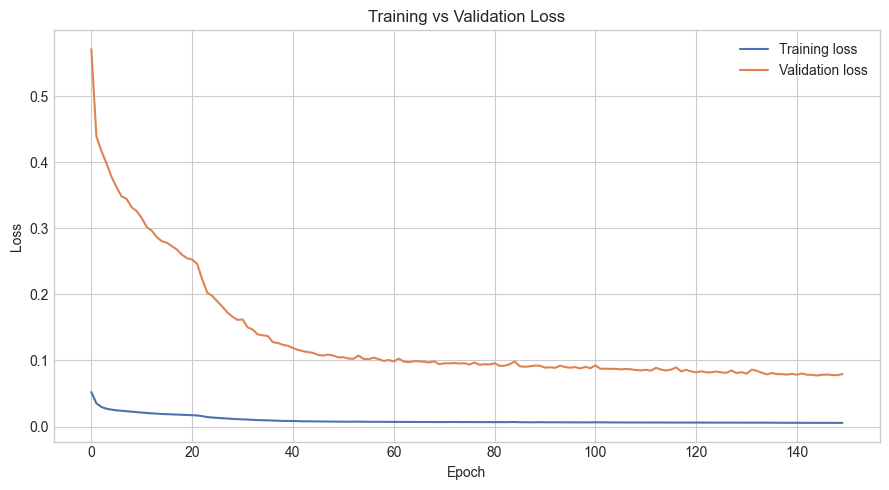

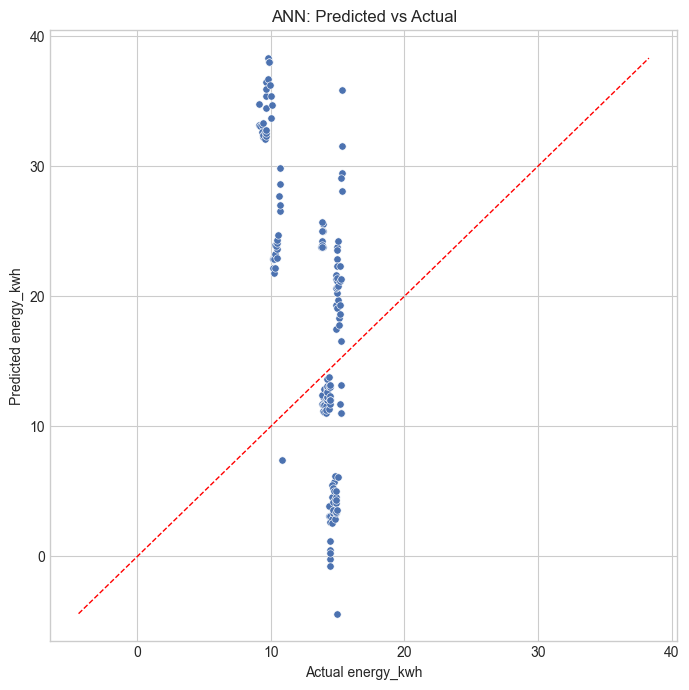

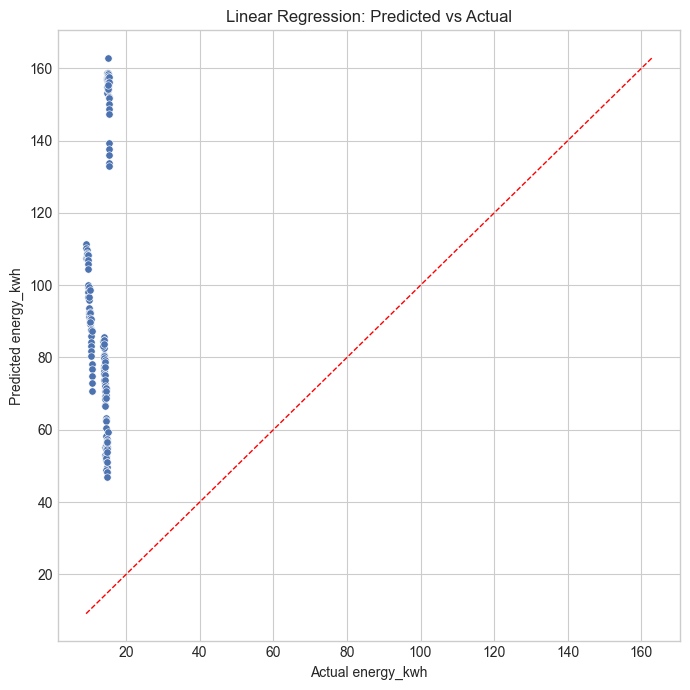

Saved model to artifacts\ann_model.joblib


In [28]:
def plot_training_history(history_obj):
    plt.figure(figsize=(9, 5))
    plt.plot(history_obj.history['loss'], label='Training loss')
    if history_obj.history.get('val_loss'):
        plt.plot(history_obj.history['val_loss'], label='Validation loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_predicted_vs_actual(y_true, y_pred, title):
    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=y_true, y=y_pred, s=28)
    min_value = min(np.min(y_true), np.min(y_pred))
    max_value = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], 'r--', linewidth=1)
    plt.xlabel('Actual energy_kwh')
    plt.ylabel('Predicted energy_kwh')
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_training_history(history)
plot_predicted_vs_actual(y_test_true, ann_pred, 'ANN: Predicted vs Actual')
plot_predicted_vs_actual(y_test_true, baseline_pred, 'Linear Regression: Predicted vs Actual')

model_path = OUTPUT_DIR / 'ann_model.joblib'
joblib.dump(ann_model, model_path)
print(f'Saved model to {model_path}')

## 7. Summary

- The ANN is the main nonlinear regression model.
- Linear regression provides a simple baseline.
- If validation loss rises while training loss falls, increase regularization or dropout, or reduce model complexity.